In [27]:
import numpy as np
import struct
import matplotlib.pyplot as plt

In [28]:


with open(r"C:\Users\bluek\Downloads\drive-download-20260226T200557Z-1-001\train-images.idx3-ubyte",'rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    print(data.shape)
    Xtraindata = np.transpose(data.reshape((size, nrows*ncols)))

with open(r"C:\Users\bluek\Downloads\drive-download-20260226T200557Z-1-001\train-labels.idx1-ubyte",'rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    ytrainlabels = data.reshape((size,)) # (Optional)

with open(r"C:\Users\bluek\Downloads\drive-download-20260226T200557Z-1-001\t10k-images.idx3-ubyte",'rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    Xtestdata = np.transpose(data.reshape((size, nrows*ncols)))

with open(r"C:\Users\bluek\Downloads\drive-download-20260226T200557Z-1-001\t10k-labels.idx1-ubyte",'rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    ytestlabels = data.reshape((size,)) # (Optional)
        

    
traindata_imgs =  np.transpose(Xtraindata).reshape((60000,28,28))    
print(Xtraindata.shape)
print(ytrainlabels.shape)
print(Xtestdata.shape)
print(ytestlabels.shape)

(47040000,)
(784, 60000)
(60000,)
(784, 10000)
(10000,)


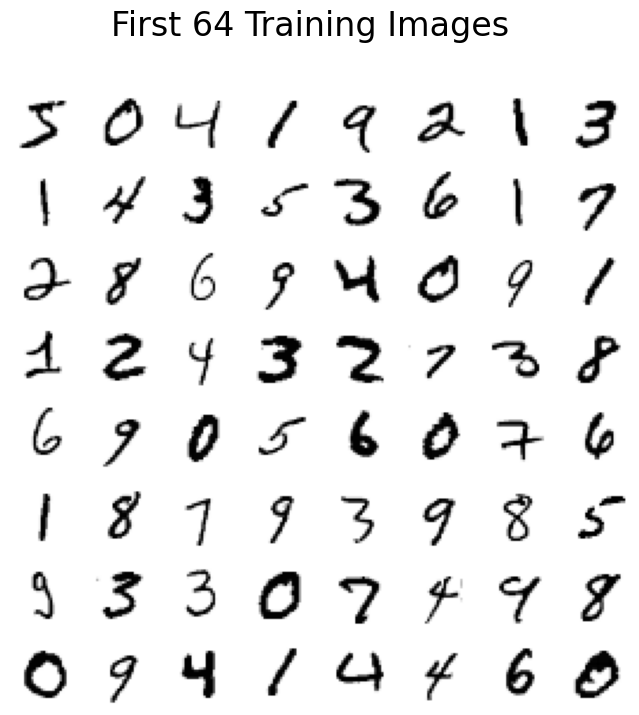

In [29]:
def plot_digits(XX, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))
    
    for i in range(N):
      for j in range(N):
        ax[i,j].imshow(XX[:,(N)*i+j].reshape((28, 28)), cmap="Greys")
        ax[i,j].axis("off")
    fig.suptitle(title, fontsize=24)

plot_digits(Xtraindata, 8, "First 64 Training Images" )


In [30]:
Xtraindata=np.transpose(Xtraindata)
Xtestdata=np.transpose(Xtestdata)
print(Xtraindata.shape)
print(ytrainlabels.shape)
print(Xtestdata.shape)
print(ytestlabels.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


Task 1

In [31]:
from sklearn.decomposition import PCA
X = Xtraindata 
#
pca = PCA(n_components=16)
#
pca.fit(X)
print(pca.components_.shape) 

(16, 784)


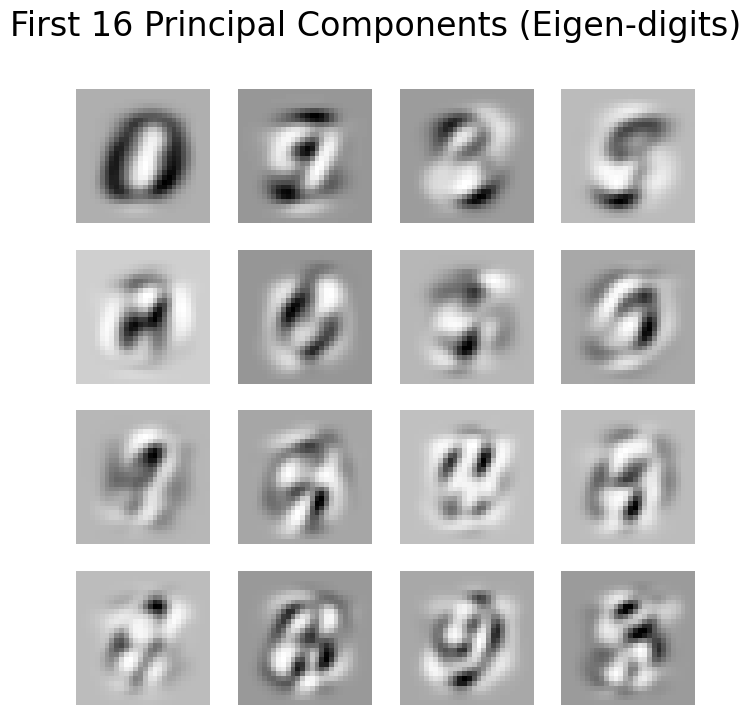

In [32]:
plot_digits(pca.components_.T, 4, "First 16 Principal Components (Eigen-digits)")

In [33]:
print(pca.components_.T.shape)

(784, 16)


Task 2

In [35]:
pca_k = PCA(n_components=200)
pca_k.fit(X)

cumvar = np.cumsum(pca_k.explained_variance_ratio_)
k = np.argmax(cumvar >= 0.85) + 1
print(k)

pca2 = PCA(n_components=59)
pca2.fit(X)

59


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",59
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

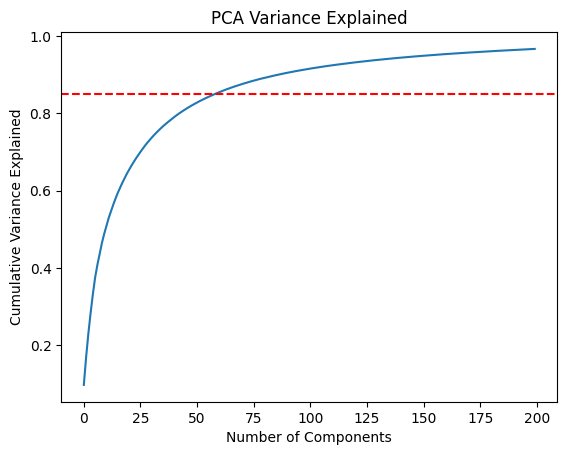

In [37]:
plt.plot(cumvar)
plt.axhline(0.85, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA Variance Explained')
plt.show()

In [38]:
pca2Transformed =pca2.transform(X)

print(pca2.inverse_transform(pca2Transformed).T.shape)


(784, 60000)


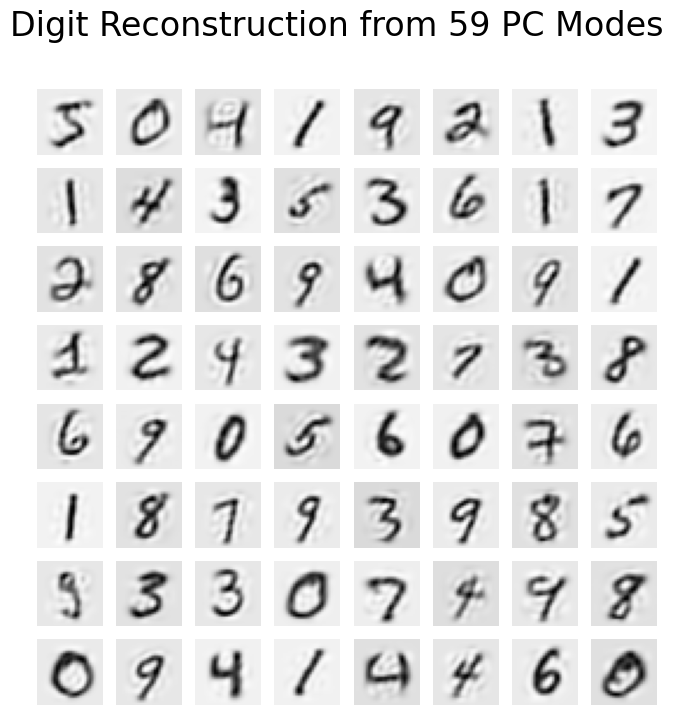

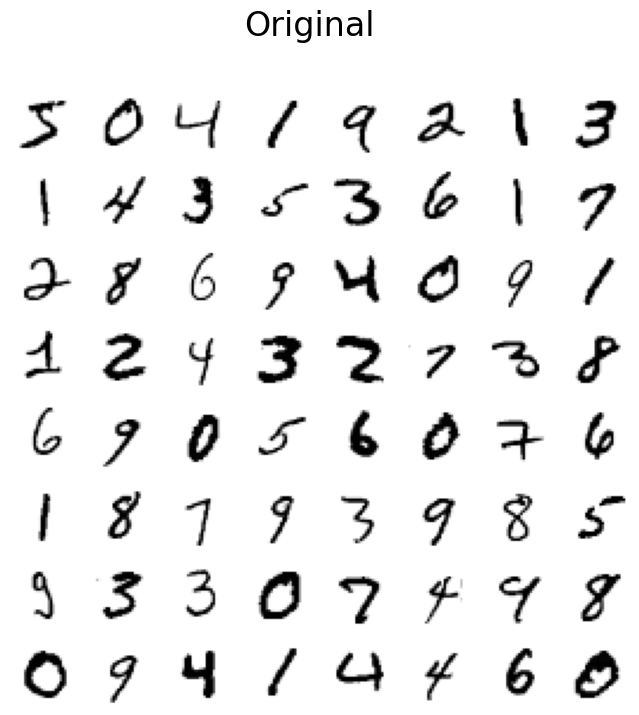

In [39]:
plot_digits(pca2.inverse_transform(pca2Transformed).T, 8, "Digit Reconstruction from 59 PC Modes" )
plot_digits(Xtraindata.T, 8, "Original" )

Task 3

In [40]:
indices = np.where((ytrainlabels == 1) | (ytrainlabels == 8))
ytrainlabels[indices] 
Xtraindata[indices]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(12593, 784), dtype=uint8)

In [41]:
def select_digits(Xtraindata, ytrainlabels, Xtestdata, ytestlabels, digits):

    indices = np.isin(ytrainlabels, digits)
    X_train_subset = Xtraindata[indices]
    y_train_subset = ytrainlabels[indices]
    
    indices_test = np.isin(ytestlabels, digits)
    X_test_subset = Xtestdata[indices_test]
    y_test_subset = ytestlabels[indices_test]
    
    return X_train_subset, y_train_subset, X_test_subset, y_test_subset


Task 4
Select the digits 1,8 using step 3, project the data onto 𝑘-PC modes computed in steps 1-2, and apply
the Ridge classifier (linear) to distinguish between these two digits. Perform cross-validation and
testing and discuss your results.


In [42]:
X_train_projected = pca2.transform(Xtraindata)
X_test_projected = pca2.transform(Xtestdata)

X_train_subset_18, y_train_subset_18, X_test_subset_18, y_test_subset_18 = select_digits(X_train_projected, ytrainlabels, X_test_projected, ytestlabels, [1, 8])



In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled_18 = scaler.fit_transform(X_train_subset_18)
X_test_scaled_18 = scaler.transform(X_test_subset_18)

y_train_binary_18 = np.where(y_train_subset_18 == 1, -1, 1)
y_test_binary_18 = np.where(y_test_subset_18 == 1, -1, 1)



In [44]:
from sklearn.linear_model import RidgeClassifier
clf = RidgeClassifier()
clf.fit(X_train_scaled_18, y_train_binary_18)

print("Test accuracy:", clf.score(X_test_scaled_18, y_test_binary_18))

from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, X_train_scaled_18, y_train_binary_18, cv=5)
print("CV scores:", scores)
print("CV mean:", scores.mean())

Test accuracy: 0.9800853485064012
CV scores: [0.96188964 0.96109567 0.96625645 0.96386021 0.96822875]
CV mean: 0.9642661444191736


Task 5: Select the digits 1,8 using step 3, project the data onto 𝑘-PC modes computed in steps 1-2, and apply
logistic regression to distinguish between these two digits. Do not include a regularization term. Discuss
your results, and compare with the ridge classifier.

In [45]:
X_train_projected = pca2.transform(Xtraindata)
X_test_projected = pca2.transform(Xtestdata)

X_train_subset_18, y_train_subset_18, X_test_subset_18, y_test_subset_18 = select_digits(X_train_projected, ytrainlabels, X_test_projected, ytestlabels, [1, 8])



In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_subset_18)
X_test_scaled = scaler.transform(X_test_subset_18)





In [47]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')
logReg = LogisticRegression(C=np.inf)
logReg.fit(X_train_scaled, y_train_subset_18)

print("Test accuracy:", logReg.score(X_test_scaled, y_test_subset_18))

from sklearn.model_selection import cross_val_score
scores = cross_val_score(logReg, X_train_scaled, y_train_subset_18, cv=5)
print("CV scores:", scores)
print("CV mean:", scores.mean())

Test accuracy: 0.9919393077287814
CV scores: [0.97935689 0.98173879 0.98689956 0.97934869 0.9833201 ]
CV mean: 0.9821328041909287


Task 6: Repeat the same Ridge and logistic classification procedures for pairs of digits 3,8 and 2,7. Report
your results and compare them with the results in step 4 and 5.

In [48]:
X_train_subset_38, y_train_subset_38, X_test_subset_38, y_test_subset_38 = select_digits(X_train_projected, ytrainlabels, X_test_projected, ytestlabels, [3, 8])

X_train_subset_27, y_train_subset_27, X_test_subset_27, y_test_subset_27 = select_digits(X_train_projected, ytrainlabels, X_test_projected, ytestlabels, [2, 7])


In [49]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import warnings

def classify_digits(X_train_subset, y_train_subset, X_test_subset, y_test_subset):
    # 1. Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_subset)
    X_test_scaled = scaler.transform(X_test_subset)
    digits = np.unique(y_train_subset)
    y_train_binary = np.where(y_train_subset == digits[0], -1, 1)
    y_test_binary = np.where(y_test_subset == digits[0], -1, 1)

    
    # 2. Fit Ridge and get CV + test scores

    clf = RidgeClassifier()
    clf.fit(X_train_scaled, y_train_binary)

    test_score_ridge = clf.score(X_test_scaled, y_test_binary)

    scores_ridge = cross_val_score(clf, X_train_scaled, y_train_binary, cv=5)
    

    # 3. Fit Logistic and get CV + test scores
    warnings.filterwarnings('ignore')
    logReg = LogisticRegression(C=np.inf)
    logReg.fit(X_train_scaled, y_train_subset)

    test_score_logistic = logReg.score(X_test_scaled, y_test_subset)

    
    scores_logistic = cross_val_score(logReg, X_train_scaled, y_train_subset, cv=5)
    
    # 4. Return/print results
    print("Ridge CV scores:", scores_ridge)
    print("Ridge Test score:", test_score_ridge)
    print("Logistic CV scores:", scores_logistic)
    print("Logistic Test score:", test_score_logistic)

In [50]:
print("Digits 1 vs 8:")
classify_digits(X_train_subset_18, y_train_subset_18, X_test_subset_18, y_test_subset_18)

print("\nDigits 3 vs 8:")
classify_digits(X_train_subset_38, y_train_subset_38, X_test_subset_38, y_test_subset_38)

print("\nDigits 2 vs 7:")
classify_digits(X_train_subset_27, y_train_subset_27, X_test_subset_27, y_test_subset_27)

Digits 1 vs 8:
Ridge CV scores: [0.96188964 0.96109567 0.96625645 0.96386021 0.96822875]
Ridge Test score: 0.9800853485064012
Logistic CV scores: [0.97935689 0.98173879 0.98689956 0.97934869 0.9833201 ]
Logistic Test score: 0.9919393077287814

Digits 3 vs 8:
Ridge CV scores: [0.95619524 0.95285774 0.96744574 0.95283806 0.96452421]
Ridge Test score: 0.9642137096774194
Logistic CV scores: [0.96537338 0.96036713 0.97495826 0.96202003 0.96869783]
Logistic Test score: 0.9657258064516129

Digits 2 vs 7:
Ridge CV scores: [0.98118609 0.97791411 0.9791411  0.9787234  0.98158756]
Ridge Test score: 0.974757281553398
Logistic CV scores: [0.98486708 0.98486708 0.98445808 0.98199673 0.9893617 ]
Logistic Test score: 0.9805825242718447


Task 7: Use all the digits and perform multi-class classification with Ridge and KNN classifiers. Report your
results and discuss how they compare between the methods. Which method performs the best?

In [51]:
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_projected)
X_test_scaled = scaler.transform(X_test_projected)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, ytrainlabels)
print("KNN Test accuracy:", knn.score(X_test_scaled, ytestlabels))

scores = cross_val_score(knn, X_train_scaled, ytrainlabels, cv=5)
print("KNN CV scores:", scores)
print("KNN CV mean:", scores.mean())

KNN Test accuracy: 0.9595
KNN CV scores: [0.9605     0.9625     0.95633333 0.95883333 0.96158333]
KNN CV mean: 0.9599499999999999


In [52]:
ytrainlabels_int = ytrainlabels.astype(int)
ytestlabels_int = ytestlabels.astype(int)

clf = RidgeClassifier()

clf.fit(X_train_scaled, ytrainlabels_int)

print("Ridge Test accuracy:", clf.score(X_test_scaled, ytestlabels_int))

scores_ridge = cross_val_score(clf, X_train_scaled, ytrainlabels_int, cv=5)
print("Ridge CV scores:", scores_ridge)
print("Ridge CV mean:", scores_ridge.mean())

Ridge Test accuracy: 0.8561
Ridge CV scores: [0.85       0.83325    0.83641667 0.84058333 0.86008333]
Ridge CV mean: 0.8440666666666667
